In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

In [2]:
PALETA = ["#67AE6E", "#DDA853", "#94B4C1", "#BE3535"]


def set_style(mode='presentacion'):
    FECEOLOR = "#F5F5DC"
    EDGECOLOR = "#000"
    GRIDCOLOR = "#222222"
    """
    Configura estilos de seaborn/matplotlib según el modo:
      - 'presentacion': tipografía grande, fondo beige y rejilla destacada.
      - 'reporte': tipografía más pequeña, fondo blanco y rejilla suave.
    """
    context = "talk"
    rc = {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": 12,
        # titulo
        "figure.titlesize": 38,
        "figure.titleweight": "bold",
        # ejes
        "axes.titlesize": 38,
        "xtick.labelsize": 26,
        "ytick.labelsize": 26,
        "axes.titlepad": 10,
        "axes.facecolor": FECEOLOR,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.edgecolor": EDGECOLOR,
        "axes.grid": True,
        # ejes rejilla
        "grid.color": GRIDCOLOR,
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
        "grid.alpha": 0.5,
        # ejes etiquetas
        "axes.labelsize": 2,
        # pad entre eje y etiquetas de valores
        "xtick.major.pad": 15,
        "ytick.major.pad": 15,
        # pad entre el nombre del eje y los ticks
        "axes.labelpad": 20,
        # leyenda
        "legend.fontsize": 18,
        "legend.title_fontsize": 20,
        "legend.labelspacing": 1.5,
        "legend.handlelength": 2,
        "legend.handleheight": 0.5,
        "legend.borderpad": 0.5,
        "legend.borderaxespad": 0.5,
        "legend.markerscale": 1.5,
        "legend.framealpha": 0.8,
        "legend.loc": "best",
        "legend.facecolor": FECEOLOR,
        "legend.shadow": True,
        "legend.edgecolor": EDGECOLOR,
        "legend.frameon": True,
        # fondo
        "figure.facecolor": FECEOLOR,
        # figura resolucion y tamaño
        "figure.dpi": 120,
        "figure.figsize": (12, 8),

        "patch.edgecolor": EDGECOLOR,   # color del borde
        "patch.linewidth": 1.0,         # grosor del borde
        "lines.markeredgecolor": EDGECOLOR,
        "lines.markeredgewidth": 1.5,
    }

    sns.set_theme(context=context, palette=PALETA, rc=rc)
    plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETA)

set_style('reporte')

In [3]:
cols_unpd = ['IndicatorName', 'IndicatorShortName', 'Time', 'Iso3', 'PAIS_ESPANIOL', 'Age', 'Sex', 'Category', 'Value']
cols_wb = ['INDICATOR_LABEL', 'REF_AREA', 'UNIT_MEASURE_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'PAIS', 'PAIS_ESPANIOL']

unpd_df = pd.read_csv("data/UNPD_DATASET_AMERICA.csv", low_memory=False, usecols=cols_unpd)
wb_df = pd.read_csv("data/WB_ESG_AMERICA.csv", usecols=cols_wb)

Introduccion

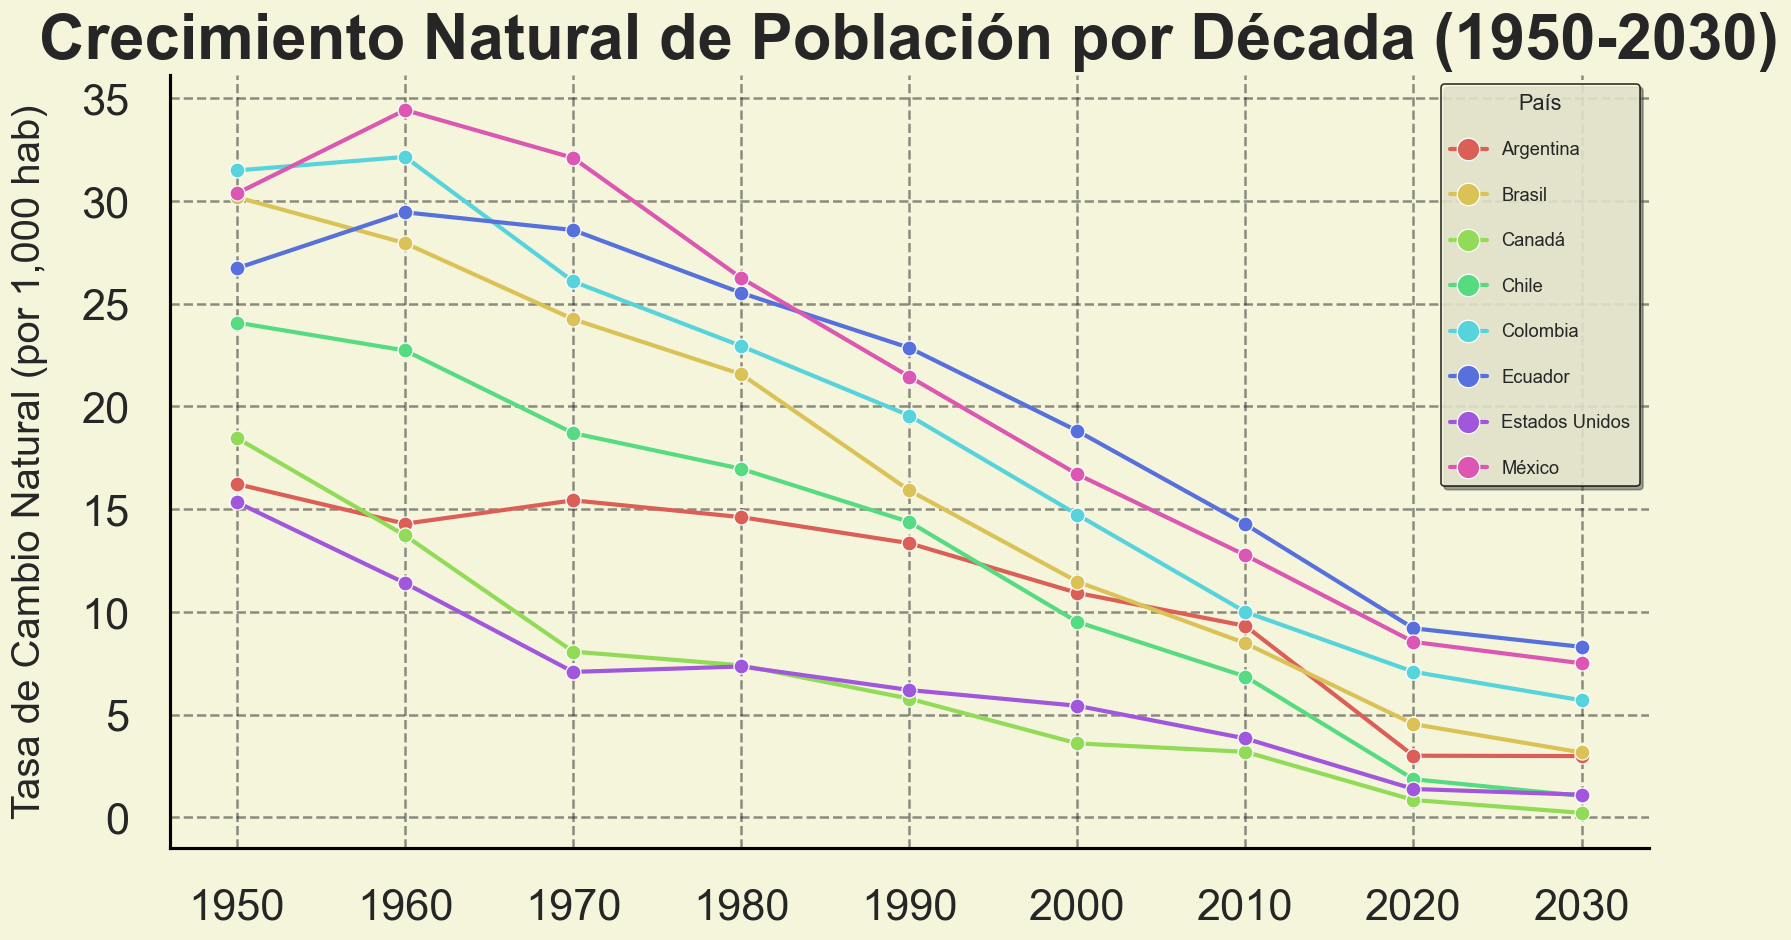

In [6]:
# Filtrar datos relevantes
natural_change = unpd_df[unpd_df['IndicatorShortName'] == 'Natural change of population']
poblacion_total = unpd_df[
    (unpd_df['IndicatorShortName'] == 'Total population by sex') & 
    (unpd_df['Sex'] == 'Both sexes')
]

# Preparar datos: unir cambio natural con población
df = pd.merge(
    natural_change[['Iso3', 'Time', 'Value', 'PAIS_ESPANIOL']],
    poblacion_total[['Iso3', 'Time', 'Value']],
    on=['Iso3', 'Time'],
    suffixes=('_cambio', '_poblacion')
)

# Calcular tasa por 1,000 hab
df['tasa_cambio'] = (df['Value_cambio'] / df['Value_poblacion']) * 1000

# Crear columna de década
df['decada'] = (df['Time'] // 10) * 10

# Filtrar países seleccionados y agrupar
paises_seleccionados = ['Argentina', 'Brasil', 'Chile', 'Colombia', 'México', 'Canadá', 'Estados Unidos', 'Ecuador']
df_filtrado = df[df['PAIS_ESPANIOL'].isin(paises_seleccionados)]
df_agrupado = df_filtrado.groupby(['PAIS_ESPANIOL', 'decada'])['tasa_cambio'].mean().reset_index()

# Configurar estilo visual
plt.figure(figsize=(14, 8))

# Generar gráfico
sns.lineplot(
    data=df_agrupado,
    x='decada',
    y='tasa_cambio',
    hue='PAIS_ESPANIOL',
    marker='o',
    linewidth=2.5,
    palette='hls'
)

# Personalizar
plt.title('Crecimiento Natural de Población por Década (1950-2030)', fontweight='bold')
plt.xlabel('')
plt.ylabel('Tasa de Cambio Natural (por 1,000 hab)', fontsize=24)
plt.xticks(df_agrupado['decada'].unique())
plt.legend(title='País', title_fontsize=13, fontsize=11)
plt.tight_layout()
plt.show()

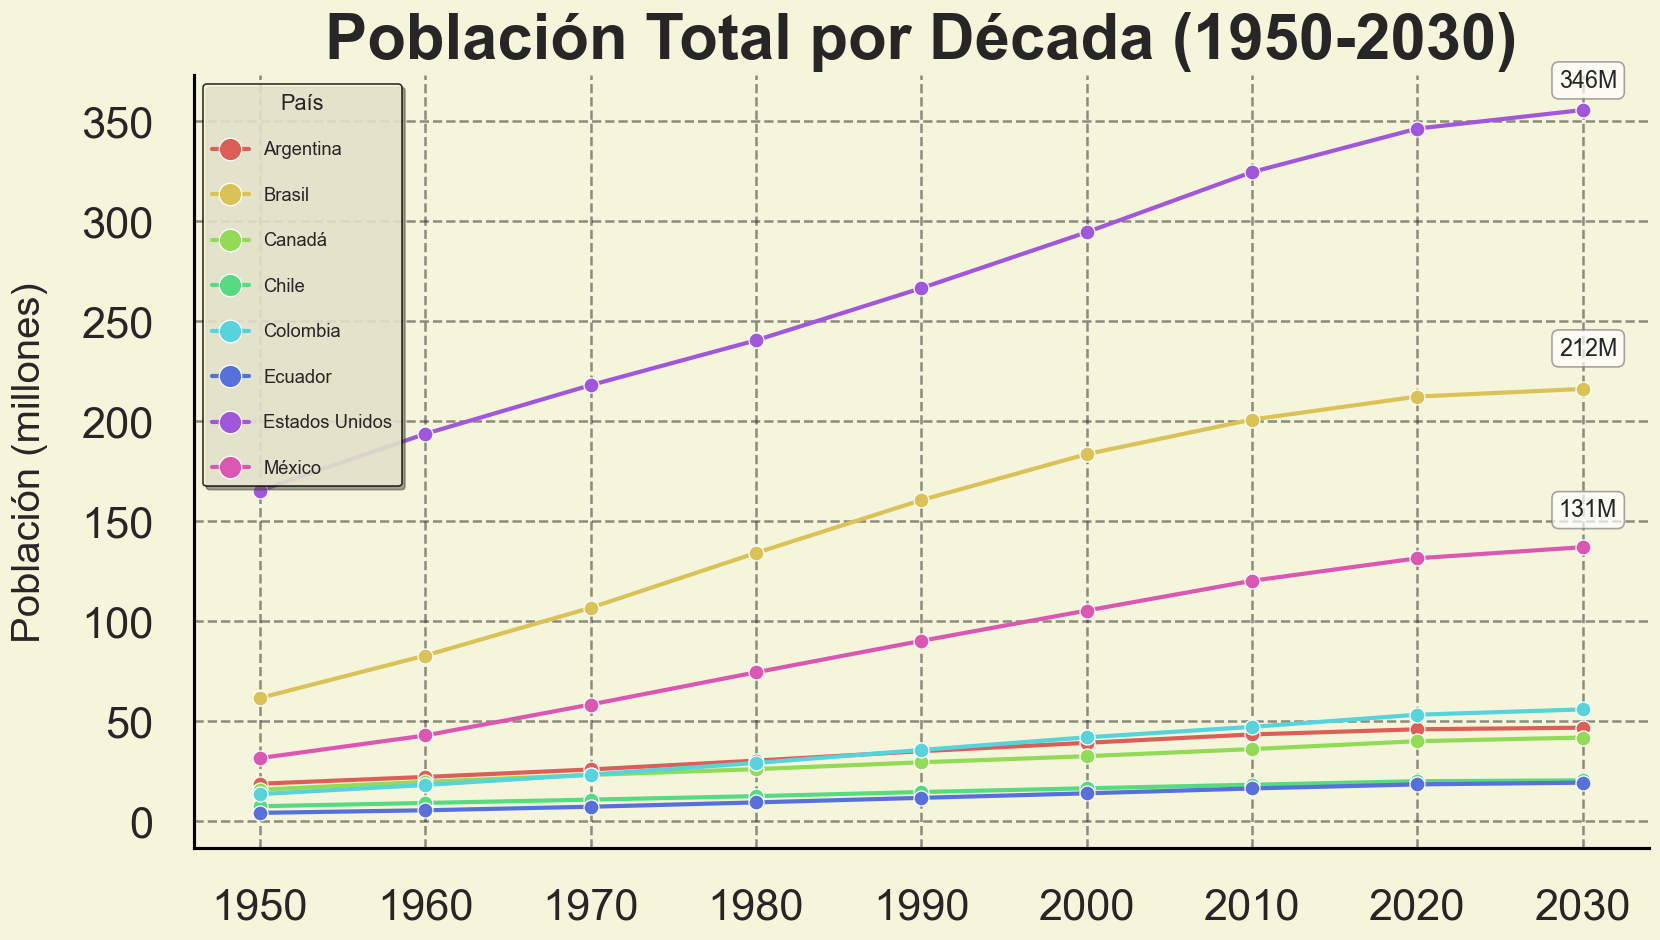

In [7]:
# Seleccionar los mismos países
df_poblacion = poblacion_total[poblacion_total['PAIS_ESPANIOL'].isin(paises_seleccionados)].copy()

# Crear columna de década y convertir a millones
df_poblacion['decada'] = (df_poblacion['Time'] // 10) * 10
df_poblacion['Poblacion_millones'] = df_poblacion['Value'] / 1_000_000

# Agrupar por década
df_agrupado_pob = df_poblacion.groupby(['PAIS_ESPANIOL', 'decada'])['Poblacion_millones'].mean().reset_index()

# Configurar el gráfico
plt.figure(figsize=(14, 8))

# Crear gráfico de líneas
sns.lineplot(
    data=df_agrupado_pob,
    x='decada',
    y='Poblacion_millones',
    hue='PAIS_ESPANIOL',
    marker='o',
    linewidth=2.5,
    palette='hls',
    legend='full'
)

# Personalización
plt.title('Población Total por Década (1950-2030)', fontweight='bold')
plt.xlabel('')
plt.ylabel('Población (millones)', fontsize=24)
plt.xticks(df_agrupado_pob['decada'].unique())
plt.legend(title='País', title_fontsize=13, fontsize=11, loc='upper left')

# Añadir etiquetas para los países con mayor población en 2020
for pais in ['Brasil', 'Estados Unidos', 'México']:
    datos_pais = df_agrupado_pob[df_agrupado_pob['PAIS_ESPANIOL'] == pais]
    ultimo_valor = datos_pais[datos_pais['decada'] == 2020].iloc[0]
    plt.annotate(f'{ultimo_valor["Poblacion_millones"]:.0f}M', 
                 (ultimo_valor['decada'], ultimo_valor['Poblacion_millones']),
                 textcoords="offset points", 
                 xytext=(85,25), 
                 ha='left',
                 fontsize=14,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))

plt.tight_layout()
plt.show()

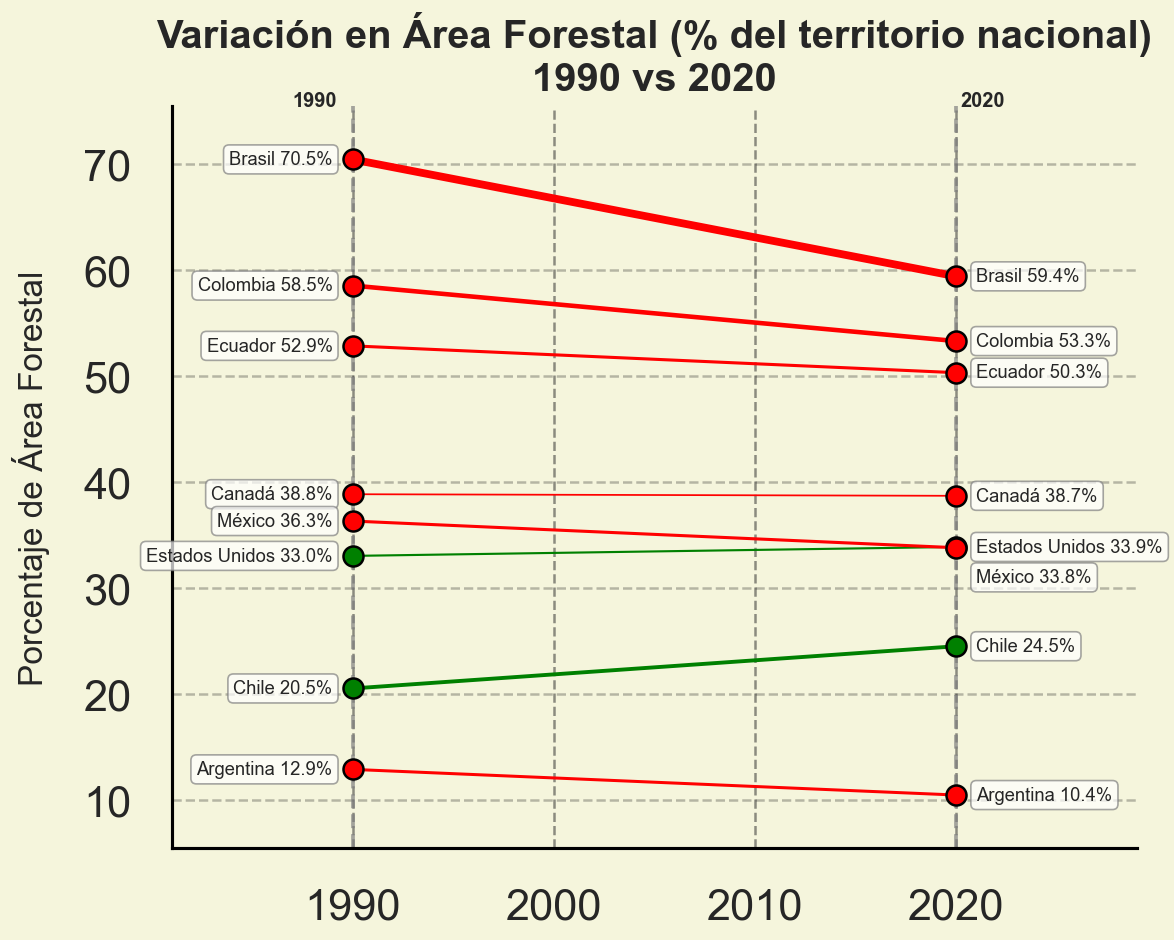

In [8]:
# Filtrar datos relevantes del World Bank
forest_data = wb_df[
    (wb_df['INDICATOR_LABEL'] == 'Forest area (% of land area)') &
    (wb_df['TIME_PERIOD'].isin([1990, 2020])) &
    (wb_df['PAIS_ESPANIOL'].isin(paises_seleccionados))
]

# Pivotar datos para tener columnas separadas por año
forest_pivot = forest_data.pivot_table(
    index='PAIS_ESPANIOL',
    columns='TIME_PERIOD',
    values='OBS_VALUE'
).reset_index()

# Renombrar columnas para claridad
forest_pivot.columns = ['País', '1990', '2020']

# Función para posicionar etiquetas
def add_label(pais, year):
    # Obtener valor
    valor = forest_pivot.loc[forest_pivot['País'] == pais, str(year)].values[0]

    # Determinar posición x
    if year == 1990:
        x_position = year - 1
    else:
        x_position = year + 1

    # Determinar posición y
    if pais == 'México' and year == 2020:
        y_offset = -2.8
    else:
        y_offset = 0
    
    # Agregar texto
    plt.text(x_position, 
             valor + y_offset, 
             f'{pais} {valor:.1f}%', 
             fontsize=11,
             ha='right' if year == 1990 else 'left',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
             va='center')

# Configurar figura
plt.figure(figsize=(10, 8))

# Líneas verticales para los años
plt.axvline(x=1990, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=2020, color='gray', linestyle='--', alpha=0.7)

# Textos BEFORE/AFTER
plt.text(1989.2, max(forest_pivot[['1990', '2020']].max()) + 5, '1990', 
         fontsize=12, fontweight='bold', ha='right')
plt.text(2020.2, max(forest_pivot[['1990', '2020']].max()) + 5, '2020', 
         fontsize=12, fontweight='bold', ha='left')

# Trazar líneas para cada país
for idx, row in forest_pivot.iterrows():
    # Determinar color según cambio
    color = 'green' if row['2020'] > row['1990'] else 'red'
    
    # Grosor de línea proporcional al cambio absoluto
    linewidth = 1 + abs(row['2020'] - row['1990'])/3
    
    plt.plot([1990, 2020], 
             [row['1990'], row['2020']], 
             marker='o',
             markersize=12,
             color=color,
             linewidth=linewidth,
             label=row['País'])
    
    # Añadir etiquetas
    add_label(row['País'], 1990)
    add_label(row['País'], 2020)

# Añadir título y ajustes
plt.title('Variación en Área Forestal (% del territorio nacional)\n1990 vs 2020', fontsize=24, fontweight='bold')
plt.ylabel('Porcentaje de Área Forestal', fontsize=20)
plt.xlabel('')
plt.ylim(min(forest_pivot[['1990', '2020']].min()) - 5, 
         max(forest_pivot[['1990', '2020']].max()) + 5)
plt.xlim(1981, 2029)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

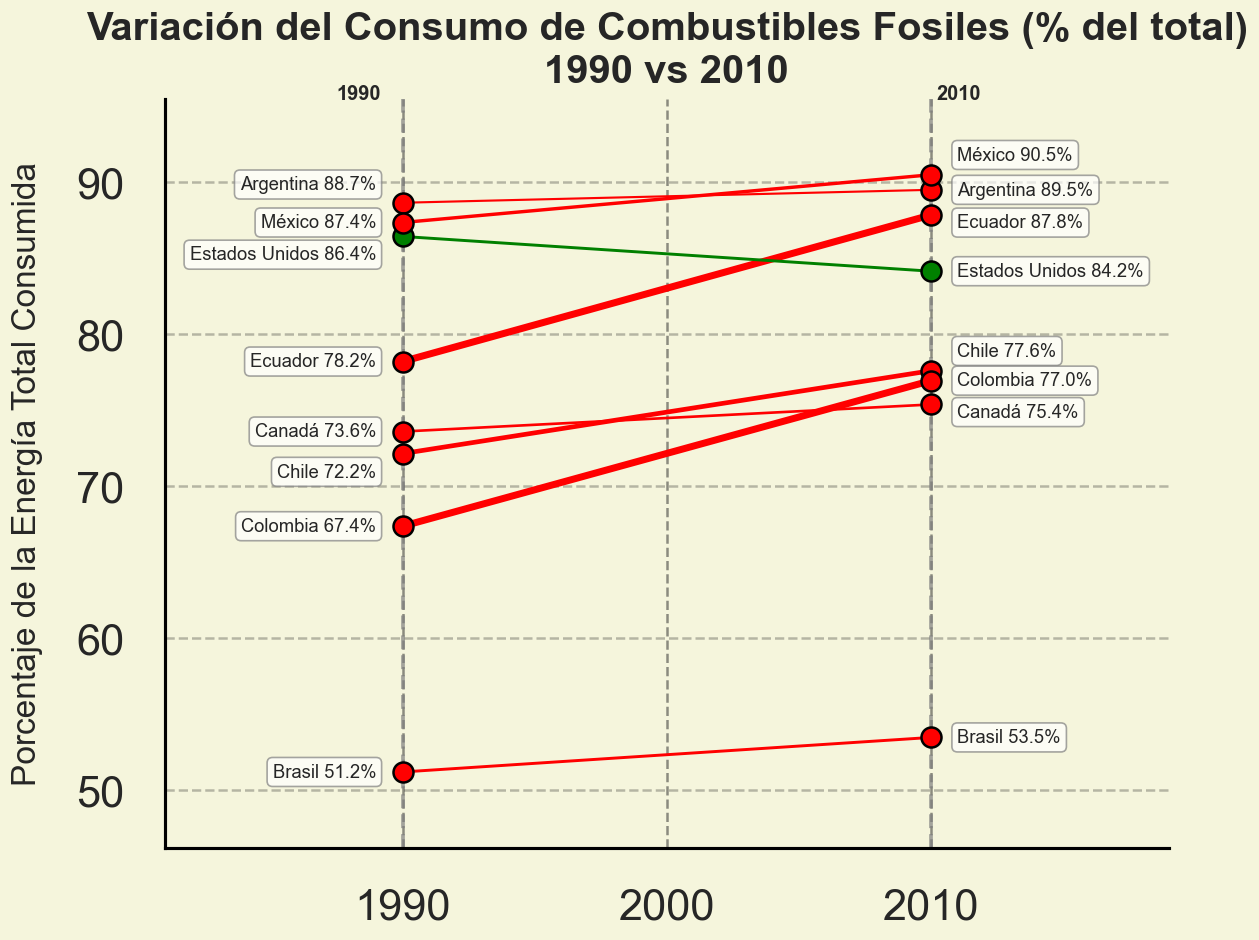

In [9]:
# Filtrar datos relevantes del World Bank
fuel_data = wb_df[
    (wb_df['INDICATOR_LABEL'] == 'Fossil fuel energy consumption (% of total)') &
    (wb_df['TIME_PERIOD'].isin([1990, 2010])) &
    (wb_df['PAIS_ESPANIOL'].isin(paises_seleccionados))
]

# Pivotar datos para tener columnas separadas por año
fuel_pivot = fuel_data.pivot_table(
    index='PAIS_ESPANIOL',
    columns='TIME_PERIOD',
    values='OBS_VALUE'
).reset_index()

# Renombrar columnas para claridad
fuel_pivot.columns = ['País', '1990', '2010']

# Función para posicionar etiquetas
def add_label(pais, year):
    # Obtener valor
    valor = fuel_pivot.loc[fuel_pivot['País'] == pais, str(year)].values[0]

    # Determinar posición x
    if year == 1990:
        x_position = year - 1
    else:
        x_position = year + 1

    # Determinar posición y
    if (pais == 'Canada' or pais == 'Argentina') and year == 1990:
        y_offset = 1.2
    elif (pais == 'Estados Unidos' or pais == 'Chile')and year == 1990:
        y_offset = -1.2
    elif (pais == 'México' or pais == 'Chile') and year == 2010:
        y_offset = 1.3
    elif (pais == 'Ecuador' or pais == 'Canadá') and year == 2010:
        y_offset = -0.5
    else:
        y_offset = 0
    # Agregar texto
    plt.text(x_position, 
             valor + y_offset,
             f'{pais} {valor:.1f}%', 
             fontsize=11,
             ha='right' if year == 1990 else 'left',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
             va='center')

# Configurar figura
plt.figure(figsize=(10, 8))

# Líneas verticales para los años
plt.axvline(x=1990, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=2010, color='gray', linestyle='--', alpha=0.7)

# Textos BEFORE/AFTER
plt.text(1989.2, max(fuel_pivot[['1990', '2010']].max()) + 5, '1990', 
         fontsize=12, fontweight='bold', ha='right')
plt.text(2010.2, max(fuel_pivot[['1990', '2010']].max()) + 5, '2010', 
         fontsize=12, fontweight='bold', ha='left')

# Trazar líneas para cada país
for idx, row in fuel_pivot.iterrows():
    # Determinar color según cambio
    color = 'red' if row['2010'] > row['1990'] else 'green'
    
    # Grosor de línea proporcional al cambio absoluto
    linewidth = 1 + abs(row['2010'] - row['1990'])/3
    
    plt.plot([1990, 2010], 
             [row['1990'], row['2010']], 
             marker='o',
             markersize=12,
             color=color,
             linewidth=linewidth,
             label=row['País'])
    
    # Añadir etiquetas
    add_label(row['País'], 1990)
    add_label(row['País'], 2010)

# Añadir título y ajustes
plt.title('Variación del Consumo de Combustibles Fosiles (% del total)\n1990 vs 2010', fontsize=24, fontweight='bold')
plt.ylabel('Porcentaje de la Energía Total Consumida', fontsize=20)
plt.xlabel('')
plt.ylim(min(fuel_pivot[['1990', '2010']].min()) - 5, 
         max(fuel_pivot[['1990', '2010']].max()) + 5)
plt.xlim(1981, 2019)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

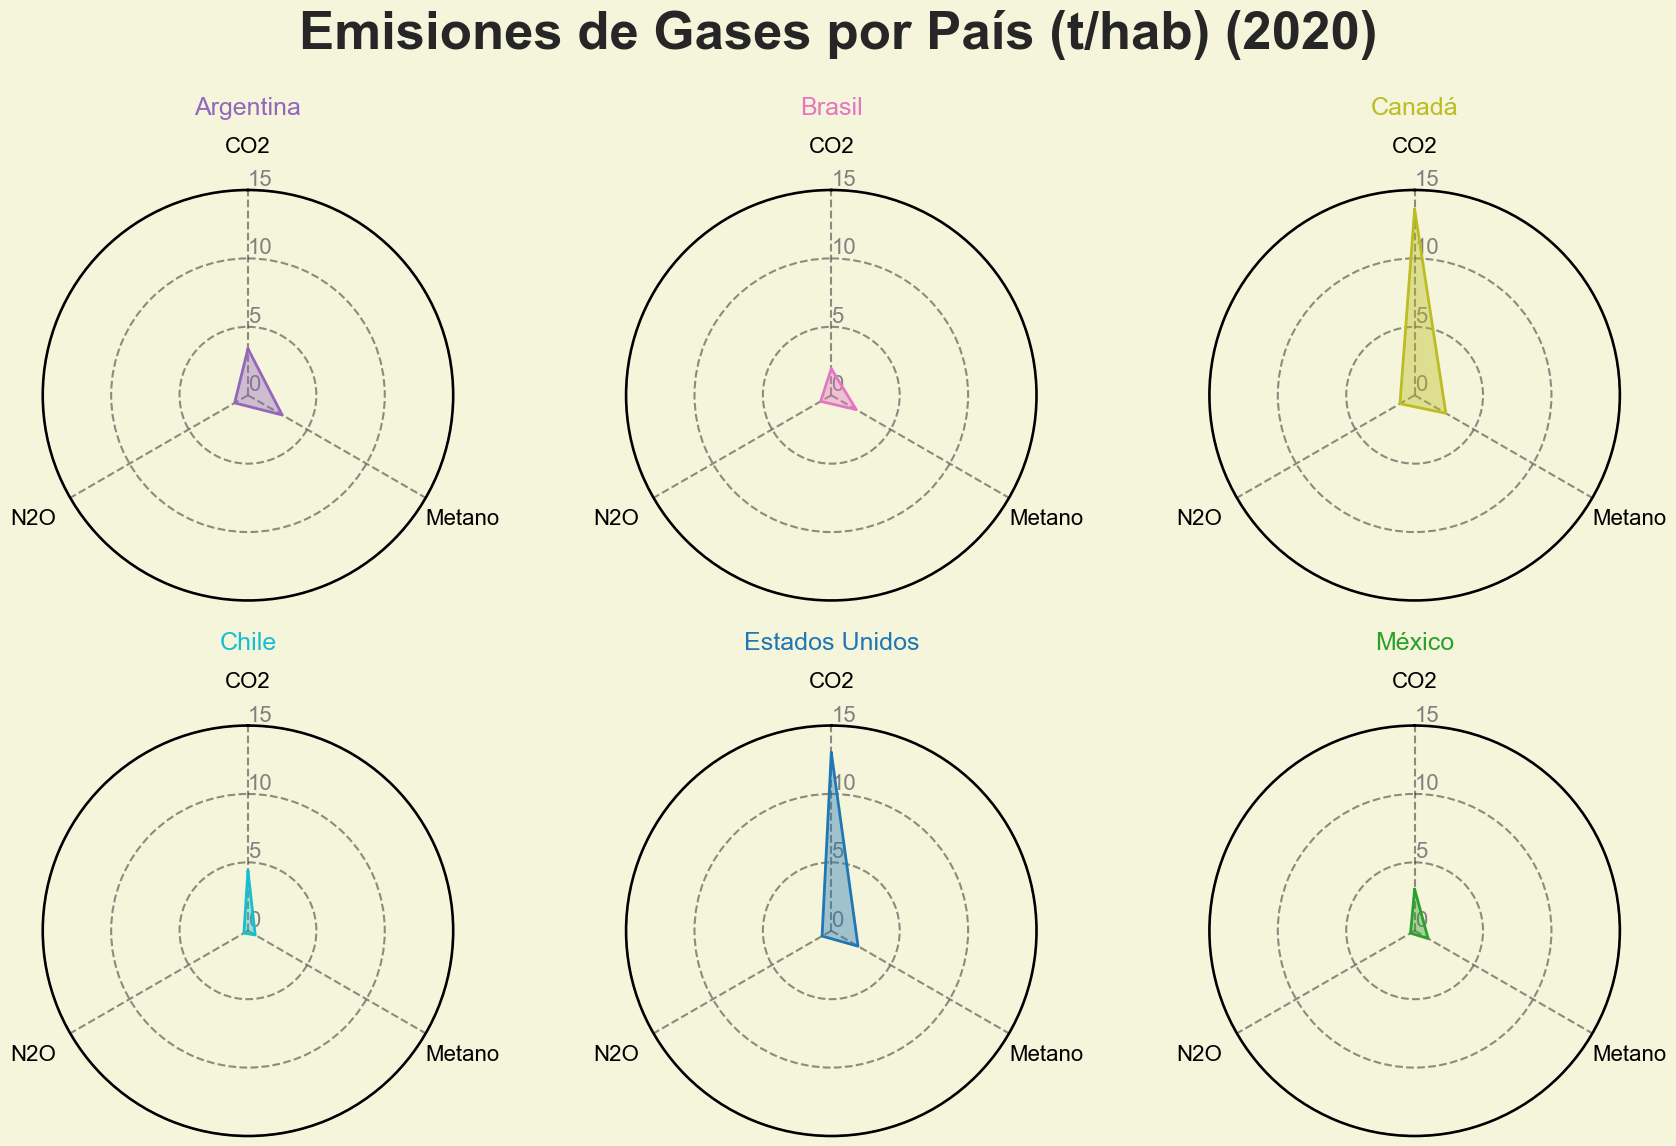

In [11]:
# Seleccionar países e indicadores
selected_countries = ['Estados Unidos', 'México', 'Argentina', 'Brasil', 'Canadá', 'Chile']
selected_indicators = [
    'CO2 emissions (metric tons per capita)',
    'Methane emissions (metric tons of CO2 equivalent per capita)',
    'Nitrous oxide emissions (metric tons of CO2 equivalent per capita)'
]

# Filtrar y preparar datos
df = wb_df[
    (wb_df['PAIS_ESPANIOL'].isin(selected_countries)) &
    (wb_df['INDICATOR_LABEL'].isin(selected_indicators)) &
    (wb_df['TIME_PERIOD'] == 2020)  # Usar el año más reciente disponible
]

# Pivotar datos
pivot_df = df.pivot_table(
    index='PAIS_ESPANIOL',
    columns='INDICATOR_LABEL',
    values='OBS_VALUE',
    aggfunc='mean'
).reset_index()

normalizar = ['CO2 emissions (metric tons per capita)',
'Methane emissions (metric tons of CO2 equivalent per capita)',
'Nitrous oxide emissions (metric tons of CO2 equivalent per capita)']

# Normalizar datos (0-100) para comparación
normalized_df = pivot_df.copy()
for indicator in normalizar:
    if indicator in pivot_df.columns:
        min_val = pivot_df[indicator].min()
        max_val = pivot_df[indicator].max()
        normalized_df[indicator] = 100 * (pivot_df[indicator] - min_val) / (max_val - min_val)

# Acortar nombres de indicadores para visualización
short_names = {
    'CO2 emissions (metric tons per capita)': 'CO2',
    'Methane emissions (metric tons of CO2 equivalent per capita)': 'Metano',
    'Nitrous oxide emissions (metric tons of CO2 equivalent per capita)': 'N2O'
}

# Configurar figura
plt.figure(figsize=(18, 12), dpi=100)
my_palette = plt.get_cmap("tab10", len(selected_countries))

# Función para crear cada gráfico de radar
def make_spider(row, title, color):
    # Configurar ángulos
    categories = list(short_names.values())
    N = len(categories)
    angles = [n / N * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # Crear subplot polar
    ax = plt.subplot(2, 3, row+1, polar=True)
    
    # Configuración de ejes
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], categories, color='black', size=16)
    ax.set_rlabel_position(0)
    plt.yticks([0, 5, 10, 15], ["0", "5", "10", "15"], color="grey", size=16)
    plt.ylim(0, 15)
    
    # Obtener valores
    values = pivot_df.loc[row, list(short_names.keys())].values.flatten().tolist()
    values += values[:1]
    
    # Trazar gráfico
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)
    
    # Añadir título
    plt.title(title, size=18, color=color, y=1.15)

# Generar gráficos para cada país
for i, pais in enumerate(selected_countries):
    # Encontrar índice en el DataFrame
    idx = pivot_df[pivot_df['PAIS_ESPANIOL'] == pais].index[0]
    make_spider(row=idx, title=pais, color=my_palette(i))

# Ajustes finales
plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.83)
plt.suptitle('Emisiones de Gases por País (t/hab) (2020)', fontweight='bold')
plt.show()